In [1]:
import dill
with open("empirical_results/lcbench_known_cost_metrics_per_acq_all_datasets.pkl", "rb") as f:
    lcbench_metrics_per_acq = dill.load(f)
with open("empirical_results/nats_sss_known_cost_metrics_per_acq_updated.pkl", "rb") as f:
    nats_metrics_per_acq = dill.load(f)

In [2]:
metrics_per_acq = {**lcbench_metrics_per_acq, **nats_metrics_per_acq}

In [3]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'

In [4]:
best_acc_per_dataset = {
    'APSFailure': 98.9274322169059,
    'Amazon_employee_access': 94.22970223783985,
    'Australian': 86.34361233480176,
    'Fashion-MNIST': 90.17316017316017,
    'KDDCup09_appetency': 98.21818181818182,
    'MiniBooNE': 90.20315921904852,
    'adult': 83.00552211950115,
    'airlines': 63.185896391512216,
    'albert': 66.32342566397537,
    'bank-marketing': 89.32904350157517,
    'blood-transfusion-service-center': 84.14634146341463,
    'car': 93.85964912280701,
    'christine': 72.76286353467562,
    'cnae-9': 95.2247191011236,
    'connect-4': 74.46732158076527,
    'covertype': 77.46252620818426,
    'credit-g': 77.57575757575758,
    'dionis': 87.8085363545019,
    'fabert': 65.83302684810593,
    'helena': 28.352312340227748,
    'higgs': 71.86302385956238,
    'jannis': 67.02012159814707,
    'jasmine': 77.7439024390244,
    'jungle_chess_2pcs_raw_endgame_complete': 85.04394861392834,
    'kc1': 86.90647482014388,
    'kr-vs-kp': 98.10246679316889,
    'mfeat-factors': 98.63636363636363,
    'nomao': 95.9113690319177,
    'numerai28.6': 52.68837501966336,
    'phoneme': 80.98710039259674,
    'segment': 90.02624671916011,
    'shuttle': 99.75444096133751,
    'sylvine': 93.07692307692308,
    'vehicle': 78.49462365591397,
    'volkert': 62.765681026866915,
    'cifar10-valid': 90.5,
    'cifar100': 71.34,
    'ImageNet16-120': 47.4,
}

In [5]:
import numpy as np
from collections import defaultdict

# === User‐provided data and helper functions (assumed to exist) ===
# metrics_per_acq[d][acq_key]["estimated cumulative cost"]
# test_metrics_per_acq[d][acq_key]["final test error"]
# bench.query_best_final(dataset, "final_test_accuracy", "final_test_accuracy", 0)

# === Config ===
# Get all LCBench datasets (exclude NATS datasets)
nats_datasets = ['cifar10-valid', 'cifar100', 'ImageNet16-120']
lcbench_datasets = [d for d in best_acc_per_dataset.keys() if d not in nats_datasets]

lambdas       = [1e-3, 1e-4, 1e-5]
acq_order     = ['LogEIPC', 'PBGI', 'LCB', 'TS']
init          = 20

# Lambda mapping: LCBench uses 1e-4, NATS-Bench uses 1e-5
dataset_lambda = {}
for dataset in lcbench_datasets:
    dataset_lambda[dataset] = 1e-4
for dataset in nats_datasets:
    dataset_lambda[dataset] = 1e-5

# === Color and marker settings ===
color_dict = {
    'LogEIPC':      'tab:blue',
    'LogEIPC-med':  'tab:blue',
    'PBGI(1e-3)':  'tab:orange',
    'PBGI(1e-4)':  'tab:orange',
    'PBGI(1e-5)':  'tab:orange',
    'LCB':         'tab:purple',
    'UCB-LCB':     'tab:purple',
    'SRGap-med':   'tab:pink',
    'TS':          'tab:brown',
    'PRB':         'tab:brown',
    'GSS':         'tab:olive',
    'Convergence': 'tab:gray',
    'Immediate':   'tab:cyan',
    'Hindsight':   'tab:red'
}

# === Build stopping_rules for each λ ===
stopping_rules = []
for lam in lambdas:
    lam_str   = f"1e-{int(round(-np.log10(lam)))}"  # "1e-3", "1e-4", "1e-5"
    fixed_acq = f"PBGI({lam_str})"

    templates = [
        {
            'stp_key':      'PBGI',
            'is_hindsight': False,
            'condition_fn': (lambda i, seed, d, lam=lam, fa=fixed_acq: (
                i >= init and
                metrics_per_acq[d][fa][f"{fa} acq"][seed][i] >=
                metrics_per_acq[d][fa]["current best observed"][seed][i - 1]
            ))
        },
        # {
        #     'stp_key':      'LogEIPC',
        #     'is_hindsight': False,
        #     'condition_fn': (lambda i, seed, d, lam=lam, fa=fixed_acq: (
        #         i >= init and
        #         metrics_per_acq[d][fa]["LogEIPC acq"][seed][i] <= np.log(lam)
        #     ))
        # },
        {
            'stp_key':      'LogEIPC-med',
            'is_hindsight': False,
            'condition_fn': (lambda i, seed, d, fa=fixed_acq: (
                i >= init and
                metrics_per_acq[d][fa]["LogEIPC acq"][seed][i] <= (
                    np.log(0.01) +
                    np.nanmedian(metrics_per_acq[d][fa]["LogEIPC acq"][seed][1:21])
                )
            ))
        },
        {
            'stp_key':      'SRGap-med',
            'is_hindsight': False,
            'condition_fn': (lambda i, seed, d, fa=fixed_acq: (
                i >= init and
                metrics_per_acq[d][fa]["exp min regret gap"][seed][i] <=
                0.01 * np.nanmedian(
                    metrics_per_acq[d][fa]["exp min regret gap"][seed][1:21]
                )
            ))
        },
        {
            'stp_key':      'UCB-LCB',
            'is_hindsight': False,
            'condition_fn': (lambda i, seed, d, fa=fixed_acq: (
                i >= init and
                metrics_per_acq[d][fa]["regret upper bound"][seed][i] <= 0.01
            ))
        },
        {
            'stp_key':      'GSS',
            'is_hindsight': False,
            'condition_fn': (lambda i, seed, d, fa=fixed_acq: (
                i >= init and (
                    (np.nanpercentile(
                        metrics_per_acq[d][fa]["current best observed"][seed][:i+1], 75
                     ) -
                     np.nanpercentile(
                        metrics_per_acq[d][fa]["current best observed"][seed][:i+1], 25
                     )) == 0
                ) or (
                    ((metrics_per_acq[d][fa]["current best observed"][seed][i - 5] -
                      metrics_per_acq[d][fa]["current best observed"][seed][i]) /
                     (np.nanpercentile(
                        metrics_per_acq[d][fa]["current best observed"][seed][:i+1], 75
                     ) -
                      np.nanpercentile(
                        metrics_per_acq[d][fa]["current best observed"][seed][:i+1], 25
                     ))
                    ) <= 0.01
                )
            ))
        },
        {
            'stp_key':      'Convergence',
            'is_hindsight': False,
            'condition_fn': (lambda i, seed, d, fa=fixed_acq: (
                i >= init and
                metrics_per_acq[d][fa]["current best observed"][seed][i] ==
                metrics_per_acq[d][fa]["current best observed"][seed][i - 5]
            ))
        },
        {
            'stp_key':      'PRB',
            'is_hindsight': False,
            'condition_fn': (lambda i, seed, d, fa=fixed_acq: (
                i >= init and
                metrics_per_acq[d][fa]["PRB"][seed][i] >= 0.95
            ))
        },
        {
            'stp_key':      'Immediate',
            'is_hindsight': False,
            'condition_fn': (lambda i, seed, d, fa=fixed_acq: (
                i >= init
            ))
        },
        {
            'stp_key':      'Hindsight',
            'is_hindsight': True,
            'condition_fn': None
        }
    ]

    for temp in templates:
        rule = {
            'acq_key':      fixed_acq,
            'stp_key':      temp['stp_key'],
            'is_hindsight': temp['is_hindsight'],
            'marker':       's' if temp['stp_key'] == 'PBGI' else ('^' if temp['stp_key'] == 'Hindsight' else 's'),
            'color':        color_dict.get(temp['stp_key'], color_dict[fixed_acq]),
            'label':        'PBGI/LogEIPC' if temp['stp_key'] == 'PBGI' else temp['stp_key']
        }
        if temp['condition_fn'] is not None:
            rule['condition_fn'] = temp['condition_fn']
        stopping_rules.append(rule)

In [6]:
# Pre-compute cost-adjusted regret for each LCBench dataset, policy, and seed
print("Pre-computing cost-adjusted regrets for LCBench datasets...")
cost_adjusted_regrets = {}  # [lam_str][dataset][acq][rule][seed] = value
immediate_values = {}  # [lam_str][dataset][acq][seed] = value

for lam in lambdas:
    lam_str = f"1e-{int(round(-np.log10(lam)))}"
    cost_adjusted_regrets[lam_str] = {}
    immediate_values[lam_str] = {}
    
    for d in lcbench_datasets:
        if d not in metrics_per_acq:
            continue
        
        cost_adjusted_regrets[lam_str][d] = {}
        immediate_values[lam_str][d] = {}
        
        best_acc = best_acc_per_dataset[d]
        best_error = 100. - best_acc
        
        for acq in acq_order:
            fixed_acq = f"PBGI({lam_str})" if acq == 'PBGI' else acq
            
            if fixed_acq not in metrics_per_acq[d]:
                continue
            
            cost_adjusted_regrets[lam_str][d][acq] = {}
            immediate_values[lam_str][d][acq] = {}
            
            num_seeds = len(metrics_per_acq[d][fixed_acq]["estimated cumulative cost"])
            
            # Compute Immediate values
            immediate_seed_vals = []
            for seed in range(num_seeds):
                errs = metrics_per_acq[d][fixed_acq]["final test error"][seed][:201]
                costs = metrics_per_acq[d][fixed_acq]["estimated cumulative cost"][seed][:201]
                stop_idx = 0  # Immediate stops at iteration 0
                immediate_val = (errs[stop_idx] - best_error) + lam * costs[stop_idx]
                immediate_values[lam_str][d][acq][seed] = immediate_val
                immediate_seed_vals.append(immediate_val)
            
            # Compute values for each stopping rule
            for rule in stopping_rules:
                if rule['acq_key'] != f"PBGI({lam_str})":
                    continue
                
                rule_key = rule['stp_key']
                cost_adjusted_regrets[lam_str][d][acq][rule_key] = {}
                
                for seed in range(num_seeds):
                    errs = metrics_per_acq[d][fixed_acq]["final test error"][seed][:201]
                    costs = metrics_per_acq[d][fixed_acq]["estimated cumulative cost"][seed][:201]
                    
                    if rule['is_hindsight']:
                        regs = np.array(errs) - best_error + lam * np.array(costs)
                        stop_idx = int(np.argmin(regs))
                    else:
                        start_idx = init
                        stop_idx = next((i for i in range(start_idx, len(errs))
                                        if rule['condition_fn'](i, seed, d)), len(errs) - 1)
                    
                    cost_adjusted_regret = (errs[stop_idx] - best_error) + lam * costs[stop_idx]
                    cost_adjusted_regrets[lam_str][d][acq][rule_key][seed] = cost_adjusted_regret

print("Pre-computation complete!")


Pre-computing cost-adjusted regrets for LCBench datasets...
Pre-computation complete!


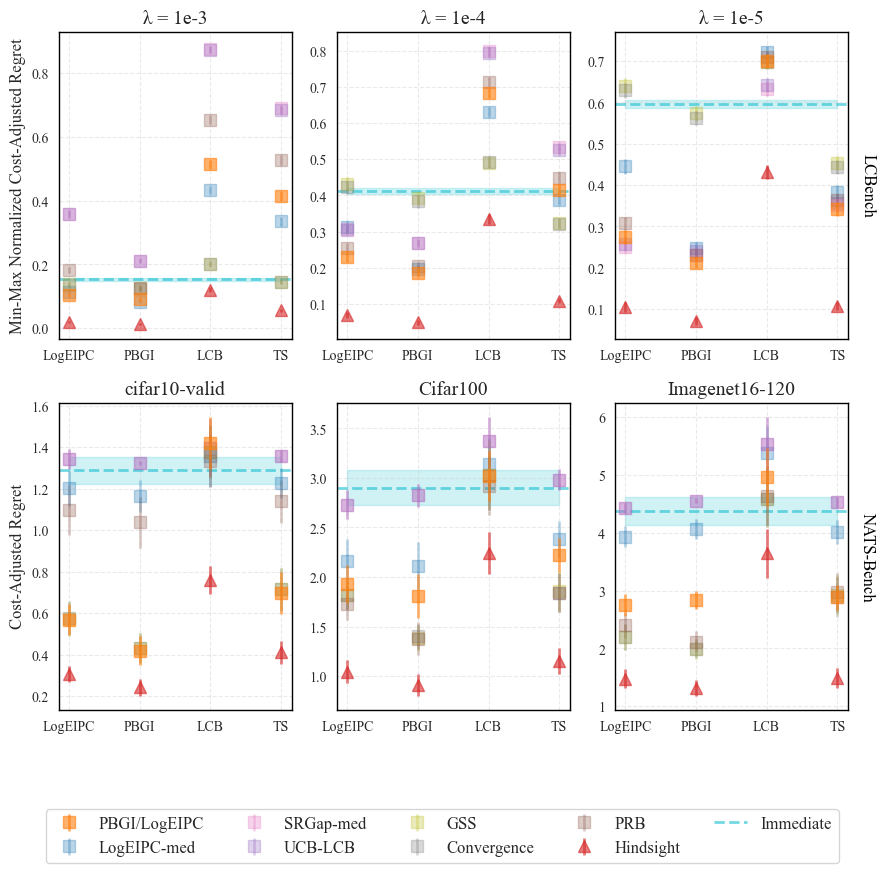

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from math import ceil

# Set style (theme first, then seaborn grid, then rcParams so sizes stick)
plt.style.use('seaborn-v0_8-bright')
sns.set_style('whitegrid', {
    'grid.linestyle': '--',
    'grid.alpha': 0.4
})
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 22,
    'axes.labelsize': 20,
    'axes.titlepad': 12,
    'figure.titlesize': 22,
    'legend.fontsize': 16,
    'legend.title_fontsize': 16,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'figure.autolayout': False,  # we'll call tight_layout() explicitly
})


def style_spines(ax, color='black', linewidth=1):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(color)
        spine.set_linewidth(linewidth)
    ax.tick_params(axis='y', which='major', labelsize=18)

n_acq_cols = len(acq_order)

# Create 2x3 subplot layout: upper row for aggregated LCBench, lower row for NATS
n_rows, n_cols = 2, 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.6 * n_cols, 4.8 * n_rows), sharey=False)
axes_flat = axes.flatten()

# ===== UPPER ROW: Aggregated LCBench datasets (one subplot per lambda) =====
for lam_idx, lam in enumerate(lambdas):
    ax = axes_flat[lam_idx]  # Upper row: indices 0, 1, 2
    lam_str = f"1e-{int(round(-np.log10(lam)))}"
    
    # Collect normalized values for each stopping rule using min-max normalization per seed
    for j, acq in enumerate(acq_order):
        for rule in stopping_rules:
            if rule['acq_key'] != f"PBGI({lam_str})":
                continue

            if rule['stp_key'] == 'Immediate':
                continue
            
            # Aggregate across all LCBench datasets with min-max normalization per seed
            all_normalized_vals = []
            for d in lcbench_datasets:
                if d not in cost_adjusted_regrets.get(lam_str, {}):
                    continue
                if acq not in cost_adjusted_regrets[lam_str][d]:
                    continue
                if rule['stp_key'] not in cost_adjusted_regrets[lam_str][d][acq]:
                    continue
                
                # Get all regrets for this dataset-seed combination across all policies
                rule_regrets = cost_adjusted_regrets[lam_str][d][acq][rule['stp_key']]
                
                # For each seed, collect all regrets across all (acq, rule) pairs to find min/max
                for seed in rule_regrets.keys():
                    # Collect all regrets for this seed across all policies
                    all_regrets_for_seed = []
                    for other_acq in acq_order:
                        other_fixed_acq = f"PBGI({lam_str})" if other_acq == 'PBGI' else other_acq
                        if other_fixed_acq not in metrics_per_acq[d]:
                            continue
                        if other_acq not in cost_adjusted_regrets[lam_str][d]:
                            continue
                        for other_rule in stopping_rules:
                            if other_rule['acq_key'] != f"PBGI({lam_str})":
                                continue
                            if other_rule['stp_key'] not in cost_adjusted_regrets[lam_str][d][other_acq]:
                                continue
                            if seed in cost_adjusted_regrets[lam_str][d][other_acq][other_rule['stp_key']]:
                                all_regrets_for_seed.append(
                                    cost_adjusted_regrets[lam_str][d][other_acq][other_rule['stp_key']][seed]
                                )
                    
                    if len(all_regrets_for_seed) > 0:
                        R_min = np.min(all_regrets_for_seed)
                        R_max = np.max(all_regrets_for_seed)
                        
                        # Get regret for this specific policy
                        R = cost_adjusted_regrets[lam_str][d][acq][rule['stp_key']][seed]
                        
                        # Min-max normalize: (R - R_min) / (R_max - R_min)
                        if R_max > R_min:
                            normalized_val = (R - R_min) / (R_max - R_min)
                        else:
                            normalized_val = 0.0  # All policies have same regret
                        
                        all_normalized_vals.append(normalized_val)
            
            if all_normalized_vals:
                mean_val = np.mean(all_normalized_vals)
                err_val = np.std(all_normalized_vals) / np.sqrt(len(all_normalized_vals))
                
                alpha = 0.6 if (rule['stp_key'] == 'PBGI' or rule['is_hindsight']) else 0.3
                zorder = 3 if rule['stp_key'] == 'PBGI' else 2
                marker = rule['marker']
                
                ax.errorbar(j, mean_val, yerr=2 * err_val,
                            fmt=marker, markersize=14, linewidth=3,
                            color=rule['color'], capsize=0,
                            alpha=alpha, zorder=zorder, label=rule['label'] if lam_idx == 0 else '')
    
    # Plot Immediate as a horizontal line (normalized value)
    immediate_normalized_vals = []
    for d in lcbench_datasets:
        if d not in cost_adjusted_regrets.get(lam_str, {}):
            continue
        for acq in acq_order:
            if acq not in cost_adjusted_regrets[lam_str][d]:
                continue
            if 'Immediate' not in cost_adjusted_regrets[lam_str][d][acq]:
                continue
            
            immediate_regrets = cost_adjusted_regrets[lam_str][d][acq]['Immediate']
            for seed in immediate_regrets.keys():
                # Collect all regrets for this seed across all policies
                all_regrets_for_seed = []
                for other_acq in acq_order:
                    other_fixed_acq = f"PBGI({lam_str})" if other_acq == 'PBGI' else other_acq
                    if other_fixed_acq not in metrics_per_acq[d]:
                        continue
                    if other_acq not in cost_adjusted_regrets[lam_str][d]:
                        continue
                    for other_rule in stopping_rules:
                        if other_rule['acq_key'] != f"PBGI({lam_str})":
                            continue
                        if other_rule['stp_key'] not in cost_adjusted_regrets[lam_str][d][other_acq]:
                            continue
                        if seed in cost_adjusted_regrets[lam_str][d][other_acq][other_rule['stp_key']]:
                            all_regrets_for_seed.append(
                                cost_adjusted_regrets[lam_str][d][other_acq][other_rule['stp_key']][seed]
                            )
                
                if len(all_regrets_for_seed) > 0:
                    R_min = np.min(all_regrets_for_seed)
                    R_max = np.max(all_regrets_for_seed)
                    R_immediate = cost_adjusted_regrets[lam_str][d][acq]['Immediate'][seed]
                    
                    if R_max > R_min:
                        normalized_val = (R_immediate - R_min) / (R_max - R_min)
                    else:
                        normalized_val = 0.0
                    immediate_normalized_vals.append(normalized_val)
    
    if immediate_normalized_vals:
        immediate_mean = np.mean(immediate_normalized_vals)
        immediate_err = np.std(immediate_normalized_vals) / np.sqrt(len(immediate_normalized_vals))
        
        ax.axhline(y=immediate_mean, xmin=0, xmax=1, 
                  color='tab:cyan', linestyle='--', linewidth=3, alpha=0.6, zorder=1)
        
        ax.fill_between([0, n_acq_cols-1], 
                       [immediate_mean - 2*immediate_err, immediate_mean - 2*immediate_err],
                       [immediate_mean + 2*immediate_err, immediate_mean + 2*immediate_err],
                       color='tab:cyan', alpha=0.2, zorder=0)
        
        if lam_idx == 0:
            ax.plot([], [], color='tab:cyan', linestyle='--', linewidth=3, 
                   alpha=0.6, label='Immediate')
    
    ax.set_xticks(range(n_acq_cols))
    ax.set_xticklabels(acq_order)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor', fontsize=18)
    ax.set_xlim(-0.5, n_acq_cols - 0.5)
    ax.set_title(f"λ = {lam_str}", fontsize=22)
    ax.grid(True, linestyle='--', alpha=0.4)
    style_spines(ax)
    
    if lam_idx == 0:
        ax.set_ylabel("Min–max normalized
cost-adjusted regret", labelpad=20, fontsize=20)
    
    # Right-side label for LCBench
    if lam_idx == n_cols - 1:
        ax.text(1.2, 0.5, 'LCBench', transform=ax.transAxes,
                rotation=-90, va='center', ha='left', fontsize=20, color='black')

# ===== LOWER ROW: NATS datasets (one subplot per dataset) =====
for nats_idx, d in enumerate(nats_datasets):
    ax = axes_flat[n_cols + nats_idx]  # Lower row: indices 3, 4, 5
    best_acc = best_acc_per_dataset[d]
    best_error = 100. - best_acc
    
    # Get dataset-specific lambda value (NATS uses 1e-5)
    lam = dataset_lambda[d]
    lam_str = f"1e-{int(round(-np.log10(lam)))}"

    # Collect Immediate values across all acquisition functions
    immediate_vals = []
    for j, acq in enumerate(acq_order):
        fixed_acq = f"PBGI({lam_str})" if acq == 'PBGI' else acq
        
        # Find Immediate rule for this acquisition function
        immediate_rule = None
        for rule in stopping_rules:
            if rule['acq_key'] == f"PBGI({lam_str})" and rule['stp_key'] == 'Immediate':
                immediate_rule = rule
                break
        
        if immediate_rule:
            stop_vals = []
            num_seeds = len(metrics_per_acq[d][fixed_acq]["estimated cumulative cost"])
            for seed in range(num_seeds):
                errs = metrics_per_acq[d][fixed_acq]["final test error"][seed][:201]
                costs = metrics_per_acq[d][fixed_acq]["estimated cumulative cost"][seed][:201]
                # Immediate stops at iteration 0
                stop_idx = 0
                stop_vals.append((errs[stop_idx] - best_error) + lam * costs[stop_idx])
            immediate_vals.extend(stop_vals)

    # Plot other stopping rules
    for j, acq in enumerate(acq_order):
        fixed_acq = f"PBGI({lam_str})" if acq == 'PBGI' else acq

        for rule in stopping_rules:
            if rule['acq_key'] != f"PBGI({lam_str})":
                continue
            
            # Skip Immediate rule here - we'll plot it separately
            if rule['stp_key'] == 'Immediate':
                continue

            stop_vals = []
            non_stopping_count = 0
            num_seeds = len(metrics_per_acq[d][fixed_acq]["estimated cumulative cost"])
            for seed in range(num_seeds):
                errs = metrics_per_acq[d][fixed_acq]["final test error"][seed][:201]
                costs = metrics_per_acq[d][fixed_acq]["estimated cumulative cost"][seed][:201]
                if rule['is_hindsight']:
                    regs = np.array(errs) - best_error + lam * np.array(costs)
                    stop_idx = int(np.argmin(regs))
                else:
                    start_idx = init  # Use init=20 for both LCBench and NATS
                    stop_idx = next((i for i in range(start_idx, len(errs))
                                    if rule['condition_fn'](i, seed, d)), len(errs) - 1)
                    if stop_idx == len(errs) - 1:
                        non_stopping_count += 1
                stop_vals.append((errs[stop_idx] - best_error) + lam * costs[stop_idx])

            mean_val = np.mean(stop_vals)
            err_val = np.std(stop_vals) / np.sqrt(len(stop_vals))

            alpha = 0.6 if (rule['stp_key'] == 'PBGI' or rule['is_hindsight']) else 0.3
            zorder = 3 if rule['stp_key'] == 'PBGI' else 2
            marker = rule['marker']
            
            ax.errorbar(j, mean_val, yerr=2 * err_val,
                        fmt=marker, markersize=14, linewidth=3,
                        color=rule['color'], capsize=0,
                        alpha=alpha, zorder=zorder, label=rule['label'] if nats_idx == 0 else '')
    
    # Plot Immediate as horizontal line with shaded error bars
    if immediate_vals:
        immediate_mean = np.mean(immediate_vals)
        immediate_err = np.std(immediate_vals) / np.sqrt(len(immediate_vals))
        
        ax.axhline(y=immediate_mean, xmin=0, xmax=1, 
                  color='tab:cyan', linestyle='--', linewidth=3, alpha=0.6, zorder=1)
        
        ax.fill_between([0, len(acq_order)-1], 
                       [immediate_mean - 2*immediate_err, immediate_mean - 2*immediate_err],
                       [immediate_mean + 2*immediate_err, immediate_mean + 2*immediate_err],
                       color='tab:cyan', alpha=0.2, zorder=0)
        
        if nats_idx == 0:
            ax.plot([], [], color='tab:cyan', linestyle='--', linewidth=3, 
                   alpha=0.6, label='Immediate')

    ax.set_xticks(range(n_acq_cols))
    ax.set_xticklabels(acq_order)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor', fontsize=18)
    ax.set_xlim(-0.5, n_acq_cols - 0.5)
    ax.set_title("cifar10-valid" if d == "cifar10-valid" else d.capitalize(), fontsize=22)
    ax.grid(True, linestyle='--', alpha=0.4)
    style_spines(ax)

    # Y label only on the leftmost column
    if nats_idx == 0:
        ax.set_ylabel("Cost-Adjusted Regret", labelpad=20, fontsize=20)

    # Right-side label for NATS-Bench
    if nats_idx == n_cols - 1:
        ax.text(1.2, 0.5, 'NATS-Bench', transform=ax.transAxes,
                rotation=-90, va='center', ha='left', fontsize=20, color='black')

# Shared legend
handles, labels = axes_flat[0].get_legend_handles_labels()
legend_hls = dict(zip(labels, handles))

# Move Immediate to the end if it exists
if 'Immediate' in legend_hls:
    immediate_handle = legend_hls.pop('Immediate')
    legend_hls['Immediate'] = immediate_handle

fig.legend(legend_hls.values(), legend_hls.keys(),
           loc='lower center', bbox_to_anchor=(0.5, -0.02),
           ncol=ceil(len(legend_hls) / 2), fontsize=16, prop={'size': 16})

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig('../plots/double_column/BarPlot_LCBench_NATS.pdf', bbox_inches='tight')
plt.show()